# Quick Start: Understanding Drought Risk in 15 Minutes

## Introduction and Objective

Welcome! In this tutorial, you'll get hands-on experience with drought risk assessment under climate change. By the end of this 15-minute session, you'll understand the fundamental concept that 

**drought risk = hazard × exposure × vulnerability**, 

and you'll have created your first drought risk map for a European region.

### The Story

Imagine you're an urban planner in Central Greece (NUTS2 region EL64). Climate change is altering drought duration, but can we see an increasing risk? Is drought duration changing (hazard), does it affect agricultural land (exposure), and does farming depend entirely on rainfall rather than irrigation (vulnerability)? The answer: all three matter.

### What You'll Learn

- The IPCC drought risk framework
- How to download and process climate hazard data from the Copernicus Climate Data Store
- How to integrate exposure and vulnerability to assess overall risk
- Where to find more detailed information on each component

### What You'll Build

A map showing historical drought risk for Central Greece, combining:
- **Hazard**: Duration of meteorological droughts (1991-2020)
- **Exposure**: Agricultural land area
- **Vulnerability**: Rainfed crop dependence

> 💡 **Note.**
> This is a very simplified example to get you started quickly. For production analysis, see our [How-To Guides](../how-to-guides.ipynb) and [Explanation](../explanation.ipynb) sections.

Let's dive in!

---

## Setup

First, let's import the libraries we'll need:

In [21]:
import cdsapi
import zipfile
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from pathlib import Path

# Create a data directory
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

---

## 1. Hazard: Historical Drought Duration

Drought hazard represents the probability and severity of drought events. We'll use data from the **European Climate Data Explorer (ECDE)** and download it from the Copernicus Climate Data Store, which provides ready-to-use drought indicators.

> 📚 **Learn more**: For details on different drought types and indices, see [What is Drought?](../explanation/what_is_drought.md)

### Download Data

We'll download the duration of meteorological drought for the entire historical period. You'll need a CDS API key - see our [How-To Guide](../how-to-guides/download_data_from_cds.ipynb) for setup instructions.

In [19]:
# Initialize CDS API client
c = cdsapi.Client()

c.retrieve(
    "sis-ecde-climate-indicators",
    {
        "variable": ["duration_of_meteorological_droughts"],
        "origin": "reanalysis",
        "temporal_aggregation": ["yearly"],
        #"spatial_aggregation": "gridded"
        "spatial_aggregation": "regional_layer",
        "regional_layer": ["nuts_level_2"]
    }, 
    str(data_dir / 'drought_duration.zip')
)

print("Download complete!")

2026-01-28 15:37:15,527 INFO Request ID is d327fc8d-5445-4b2c-88e3-e375d76b3c1c
2026-01-28 15:37:15,558 INFO status has been updated to accepted
2026-01-28 15:37:28,918 INFO status has been updated to successful


2766277e7bda0e647575745aa02571e3.zip:   0%|          | 0.00/252k [00:00<?, ?B/s]

Download complete!


> ⏱️ **Time-saving tip**: For this tutorial, we'll work with pre-processed data. In practice, this download takes 10-15 minutes.

### Unzip and Identify the Downloaded File

In [22]:
# Unzip the downloaded file
with zipfile.ZipFile(data_dir / 'drought_duration.zip', 'r') as zip_ref:
    zip_ref.extractall(data_dir)
    
# List all NetCDF files in the data directory
nc_files = list(data_dir.glob('*.nc'))

print(f"Found {len(nc_files)} NetCDF file(s):")
for nc_file in nc_files:
    print(f"  - {nc_file.name}")
    
# Use the first NetCDF file (there should only be one)
hazard_file = nc_files[0]
print(f"\nUsing file: {hazard_file.name}")

Found 1 NetCDF file(s):
  - 19_duration_of_meteorological_droughts-reanalysis-yearly-layer-nuts_2-latitude-1940-2023-v1.0.nc

Using file: 19_duration_of_meteorological_droughts-reanalysis-yearly-layer-nuts_2-latitude-1940-2023-v1.0.nc


### Load and Process Hazard Data

In [23]:
# Load the drought duration dataset
hazard_ds = xr.open_dataset(hazard_file)

# Explore the dataset structure
print("Dataset variables:", list(hazard_ds.data_vars))
print("Dataset dimensions:", dict(hazard_ds.dims))
print("Coordinate variables:", list(hazard_ds.coords))

# Display the dataset
hazard_ds

Dataset variables: ['dmd']
Dataset dimensions: {'nuts': 334, 'time': 84}
Coordinate variables: ['realization', 'time', 'nuts']


/etc/ecmwf/ssd/ssd1/jupyterhub/nejk-jupyterhub/tmpdirs/nejk.39186048/ipykernel_1625063/907422413.py:6: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("Dataset dimensions:", dict(hazard_ds.dims))


<xarray.Dataset> Size: 230kB
Dimensions:      (nuts: 334, time: 84)
Coordinates:
  * nuts         (nuts) <U4 5kB 'DE50' 'DE60' 'DE71' ... 'NO06' 'NO07' 'NO08'
  * time         (time) datetime64[ns] 672B 1940-01-01 1941-01-01 ... 2023-01-01
    realization  int64 8B ...
Data variables:
    dmd          (nuts, time) float64 224kB ...

### Filter for Central Greece and visualize hazard

In [24]:
### Filter for Central Greece (NUTS2: EL64)
# Check the NUTS codes available
print("First 10 NUTS codes:", hazard_ds['nuts'].values[:10])

# Filter for Central Greece (EL64)
hazard_region = hazard_ds.sel(nuts='EL64')

print(f"\nCentral Greece (EL64):")
print(f"Time range: {hazard_region['time'].values[0]} to {hazard_region['time'].values[-1]}")
print(f"Number of time steps: {len(hazard_region['time'])}")

First 10 NUTS codes: ['DE50' 'DE60' 'DE71' 'DE72' 'DE73' 'DE80' 'DE91' 'BG41' 'BG42' 'CH01']

Central Greece (EL64):
Time range: 1940-01-01T00:00:00.000000000 to 2023-01-01T00:00:00.000000000
Number of time steps: 84


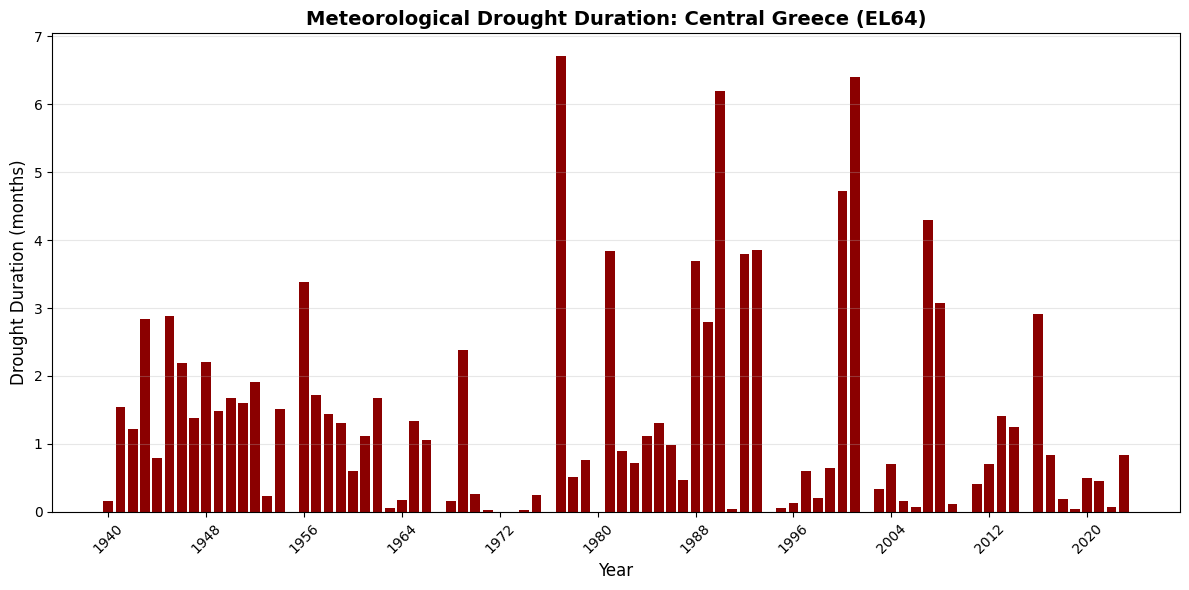


Drought Duration Statistics:
Mean: 1.30 months
Min: 0.00 months
Max: 6.71 months


In [28]:
### Visualize Hazard Time Series
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the time series as a bar chart
ax.bar(range(len(hazard_region['time'])), hazard_region['dmd'].values, color='darkred', width=0.8)

ax.set_title('Meteorological Drought Duration: Central Greece (EL64)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Drought Duration (months)', fontsize=12)
ax.set_xticks(range(0, len(hazard_region['time']), max(1, len(hazard_region['time'])//10)))
ax.set_xticklabels([str(t.astype('datetime64[Y]')) for t in hazard_region['time'].values[::max(1, len(hazard_region['time'])//10)]], rotation=45)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Print some statistics
print(f"\nDrought Duration Statistics:")
print(f"Mean: {hazard_region['dmd'].mean().values:.2f} months")
print(f"Min: {hazard_region['dmd'].min().values:.2f} months")
print(f"Max: {hazard_region['dmd'].max().values:.2f} months")

**What we see**: The time series shows how drought duration has varied over time in Central Greece, revealing major drought events and potential trends.

---

## 2. Exposure: Agricultural Land

Exposure tells us what's at stake. Not all land is equally vulnerable to drought - agricultural areas are typically more exposed than forests or urban areas.

> 📚 **Learn more**: See [Understanding Exposure](../explanation/exposure.md) for different exposure metrics.

### Download Land Cover Data

We'll use the Copernicus Land Cover dataset to identify agricultural areas, using the year 2020 as a reference:

In [ ]:
# Define bounding box for Central Greece (EL64)
# Format: [North, West, South, East]
# Approximate bounds for Central Greece
lon_min, lon_max = 21.0, 24.5
lat_min, lat_max = 38.0, 40.0

dataset = "satellite-land-cover"
request = {
    "variable": "all",
    "year": ["2020"],  # Just one year for the tutorial
    "version": ["v2_1_1"],
    "area": [lat_max, lon_min, lat_min, lon_max]  # [North, West, South, East]
}

client = cdsapi.Client()
client.retrieve(dataset, request).download(str(data_dir / 'land_cover.zip'))

print("Land cover download complete!")

2026-01-28 15:32:11,854 INFO [2025-07-04T00:00:00] Due to a transition between project phases, there are changes to the timeline of this dataset updates, which are usually on an annual basis with a one year delay: 2023 and 2024 data updates are now expected during 2026. Please watch the [forum](https://forum.ecmwf.int/c/announcements/5) for future announcements.
2026-01-28 15:32:11,855 INFO Request ID is 20d5c90f-cfee-4ae1-9d76-012cb0e70a60
2026-01-28 15:32:11,885 INFO status has been updated to accepted
2026-01-28 15:32:25,253 INFO status has been updated to running


### Process Exposure Data

In [ ]:
# Unzip the downloaded file
with zipfile.ZipFile(data_dir / 'land_cover.zip', 'r') as zip_ref:
    zip_ref.extractall(data_dir)
    
# List all NetCDF files in the data directory
nc_files = list(data_dir.glob('*.nc'))
print(f"Found {len(nc_files)} NetCDF file(s):")
for nc_file in nc_files:
    print(f"  - {nc_file.name}")
# Use the first NetCDF file (there should only be one)
lc_file = nc_files[1]
print(f"\nUsing file: {lc_file.name}")

# Load land cover data
lc_ds = xr.open_dataset(lc_file)

# Subset to our region
lc_region = lc_ds.sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_max, lat_min)
)

# Create agricultural land mask
# Land cover classes: 10-40 are various crop types
ag_mask = ((lc_region['lccs_class'] >= 10) & (lc_region['lccs_class'] <= 40))

# Calculate fraction of agricultural land per grid cell
# (In a full analysis, you might aggregate to coarser resolution)
exposure = ag_mask.astype(float)

print(f"Agricultural land coverage: {exposure.mean().values*100:.1f}%")

### Visualize Exposure

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
exposure.plot(ax=ax, cmap='Greens', cbar_kwargs={'label': 'Agricultural Land Fraction'})
ax.set_title('Drought Exposure: Agricultural Land in Central Greece')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

**What we see**: Green areas show where agricultural land is concentrated - these areas are exposed to drought impacts.

---

## 3. Combining Hazard and Exposure

Now let's see what happens when we combine hazard and exposure. This shows us where droughts occur AND where there's agricultural land at stake:

In [27]:
# Ensure both datasets are on the same grid
# (In practice, you'd use proper regridding - see How-To Guides)
exposure_regrid = exposure.interp_like(hazard_mean)

# Calculate hazard × exposure
hazard_exposure = hazard_mean * exposure_regrid

# Normalize to 0-1 scale for easier interpretation
hazard_exposure_norm = (hazard_exposure - hazard_exposure.min()) / (hazard_exposure.max() - hazard_exposure.min())

NameError: name 'hazard_mean' is not defined

### Visualize Combined Hazard × Exposure

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Hazard only
hazard_mean.plot(ax=axes[0], cmap='YlOrRd')
axes[0].set_title('Hazard Only\n(Drought Duration)')

# Plot 2: Exposure only
exposure_regrid.plot(ax=axes[1], cmap='Greens')
axes[1].set_title('Exposure Only\n(Agricultural Land)')

# Plot 3: Combined
hazard_exposure_norm.plot(ax=axes[2], cmap='RdPu', cbar_kwargs={'label': 'Normalized Impact'})
axes[2].set_title('Hazard × Exposure\n(Drought Impact on Agriculture)')

plt.tight_layout()
plt.show()

**Key insight**: The combined map shows hotspots where drought hazard overlaps with agricultural exposure - but we're still missing a crucial piece: vulnerability.

---

## 4. Vulnerability: Rainfed Agriculture Dependence

Vulnerability represents the susceptibility of exposed elements to harm. A region with extensive irrigation is less vulnerable to drought than one relying entirely on rainfall.

> 📚 **Learn more**: For the full IPCC vulnerability framework, see [Understanding Vulnerability](../explanation/vulnerability.md)

### Load Vulnerability Data

We'll use irrigation data from AQUASTAT to estimate the fraction of rainfed (non-irrigated) agriculture:

In [ ]:
# For this tutorial, we'll use simplified country-level data
# In practice, you'd want higher spatial resolution - see our How-To Guides

# Example: Greece has approximately 60% rainfed agriculture
# (This is a simplification - actual data would vary spatially)
vulnerability = xr.full_like(exposure_regrid, 0.6)

# You could refine this with actual gridded irrigation data:
# vulnerability_refined = 1 - (irrigated_area / total_agricultural_area)

print(f"Using rainfed fraction as vulnerability proxy: {vulnerability.mean().values:.2f}")

### Visualize Vulnerability

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
vulnerability.plot(ax=ax, cmap='Blues', cbar_kwargs={'label': 'Rainfed Fraction'})
ax.set_title('Drought Vulnerability: Rainfed Agriculture Dependence')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

---

## 5. The Complete Picture: Drought Risk

Now we bring it all together. **Risk = Hazard × Exposure × Vulnerability**

In [ ]:
# Calculate overall drought risk
drought_risk = hazard_mean * exposure_regrid * vulnerability

# Normalize for visualization
drought_risk_norm = (drought_risk - drought_risk.min()) / (drought_risk.max() - drought_risk.min())

### Final Comparison

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Hazard
im1 = hazard_mean.plot(ax=axes[0, 0], cmap='YlOrRd', add_colorbar=False)
axes[0, 0].set_title('(a) Hazard\nDrought Duration', fontsize=12, fontweight='bold')
plt.colorbar(im1, ax=axes[0, 0], label='Months')

# Exposure
im2 = exposure_regrid.plot(ax=axes[0, 1], cmap='Greens', add_colorbar=False)
axes[0, 1].set_title('(b) Exposure\nAgricultural Land', fontsize=12, fontweight='bold')
plt.colorbar(im2, ax=axes[0, 1], label='Fraction')

# Vulnerability
im3 = vulnerability.plot(ax=axes[1, 0], cmap='Blues', add_colorbar=False)
axes[1, 0].set_title('(c) Vulnerability\nRainfed Dependence', fontsize=12, fontweight='bold')
plt.colorbar(im3, ax=axes[1, 0], label='Fraction')

# Risk
im4 = drought_risk_norm.plot(ax=axes[1, 1], cmap='RdPu', add_colorbar=False)
axes[1, 1].set_title('(d) Risk = Hazard × Exposure × Vulnerability\nDrought Risk', 
                     fontsize=12, fontweight='bold')
plt.colorbar(im4, ax=axes[1, 1], label='Normalized Risk')

plt.tight_layout()
plt.show()

### Interpret the Results

In [ ]:
# Find the highest risk areas
risk_threshold = drought_risk_norm.quantile(0.9)
high_risk_areas = drought_risk_norm > risk_threshold

print(f"High risk areas cover {high_risk_areas.sum().values / high_risk_areas.size * 100:.1f}% of the region")
print(f"\nInterpretation:")
print(f"- Mean hazard: {hazard_mean.mean().values:.1f} months of drought")
print(f"- Agricultural exposure: {exposure_regrid.mean().values*100:.1f}% of land")
print(f"- Rainfed vulnerability: {vulnerability.mean().values*100:.1f}%")
print(f"- Overall risk is highest where all three factors coincide")

---

## Summary and Next Steps

**Congratulations!** 🎉 You've just completed your first drought risk assessment. You now understand:

1. **The risk framework**: Risk emerges from the combination of hazard, exposure, and vulnerability
2. **How to access climate data**: Using the Copernicus Climate Data Store
3. **Why all three components matter**: High hazard alone doesn't equal high risk without exposure and vulnerability

### What You Created

- A spatial map of drought risk for Central Greece
- An understanding of which factors drive risk in different locations
- A foundation for more sophisticated analysis

### Next Steps

Ready to go deeper? Here's your learning path:

**Tutorials** (hands-on practice):
- [Historical Drought Analysis](historical_drought.ipynb) - Analyze trends over time
- [Projected Drought](projected_drought.ipynb) - Explore future scenarios
- [Exposure Analysis](exposure_land.ipynb) - Work with different exposure metrics

**How-To Guides** (specific tasks):
- [Download Data from CDS](../how-to-guides/download_data_from_cds.ipynb) - Set up API access
- [Define Your Region](../how-to-guides/define_your_region.ipynb) - Work with NUTS regions
- [Compare Regions](../how-to-guides/compare_regions.ipynb) - Analyze multiple areas

**Explanation** (deeper understanding):
- [What is Drought?](../explanation/what_is_drought.md) - Meteorological, agricultural, hydrological
- [The IPCC Risk Framework](../explanation/drought_risk.md) - Conceptual foundations
- [Interpreting Results](../explanation/interpretation.md) - Common pitfalls and best practices

**References** (technical details):
- [ECDE Dataset Documentation](../references/ecde_data.md)
- [VALORADA Project](../references/valorada.md)

---

## Questions or Issues?

- Found a bug? Open an issue on our GitHub repository
- Have a question? Check our FAQ or discussion forum
- Want to contribute? See our contribution guidelines

Happy analyzing! 🌍💧